# 09 — Multimodal grounding pilot (E7, M6, RQ4)

Story notebook for Milestone 6 (PLAN.md §3 E7, §8 G3, §2 RQ4; full build log in PLAN.md §14.6). Thin (PLAN.md §6): every table and figure below was already produced by earlier tasks — the photo byte store (T6.1), the surfaced-vs-control pairing + coverage funnel (T6.3), the order-swap pairwise vision judge (T6.4), the live pilot run (T6.5), and the human spot-check (T6.6). This notebook only imports from `src/`, reads already-committed CSVs/JSONL and an already-rendered PNG, and tells the story — it makes **no API calls and needs no `GOOGLE_API_KEY`**, so re-running it top to bottom costs nothing and touches no network.

In [1]:
import json

import pandas as pd
from IPython.display import Image, display

from cragb.utils.io import resolve_path

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 100)

## Coverage funnel (T6.1/T6.3)

How many of CRAGB v1's 60 questions actually make it into the pilot, and where the rest drop out. `photo_in_context` (not `image_target`) is where nearly everything is lost — see the printed note below for why.

In [2]:
coverage = pd.read_csv(resolve_path("results/tables/mm_coverage_v1.csv"))
display(coverage)

,stage,count,description
0,total_questions,60,all CRAGB v1 questions
1,image_target,49,questions flagged image_target=true (T2.3)
2,photo_in_context,25,"image-target questions whose RAG-small retrieved context contains >=1 has-image doc, with a usab..."
3,fetchable_bytes,25,"of those, the surfaced photo AND a control photo both resolved to real, fetchable bytes"
4,usable_pairs,25,pairs written to mm_pairs_v1.jsonl (== fetchable_bytes; every fetchable pair is handed to T6.5's...


In [3]:
total = coverage.loc[coverage["stage"] == "total_questions", "count"].iloc[0]
image_target = coverage.loc[coverage["stage"] == "image_target", "count"].iloc[0]
usable = coverage.loc[coverage["stage"] == "usable_pairs", "count"].iloc[0]
print(
    f"{total} total questions -> {image_target} flagged image_target -> "
    f"{usable} usable pairs actually judged."
)

60 total questions -> 49 flagged image_target -> 25 usable pairs actually judged.


**Why the drop happens at `photo_in_context`, not `image_target`.** All 24 dropped questions had *some* image coverage in the corpus (that's what `image_target` means), but RAG-small's actual retrieved context (BM25, k=5) simply didn't happen to include one of those has-image docs for them — the pooling stage that set `image_target` looked at a 20-doc union pool, k=5 is a much narrower slice of it. PLAN.md §14.6 has the full explanation. This is a property of the pipeline as built, not a fetch failure: T6.1's real fetch over the candidate URLs succeeded at 99.2% (122/123).

## What "surfaced photo" means — and why it's the pipeline's, not the oracle's

For every image-target question, `benchmark/best_photo_v1.jsonl` (T2.9) already has a *human-picked* best-evidence photo. This pilot deliberately does not use it. `cragb.multimodal.photo_link.surfaced_photo` instead walks the RAG-small pipeline's own retrieved context, in the same rank order the pipeline actually retrieved it, and takes the first doc flagged as having a photo — the photo a user would genuinely be shown if this system shipped today. Measuring the oracle's pick instead would answer a different, easier question ("can *some* photo in this corpus be good evidence?") than the one PLAN.md §1.4 risk D and RQ4 actually ask ("is the evidence *this pipeline* surfaces any good?"). The random control (T6.3) is drawn from outside both the question's gold-relevant docs and its retrieved context, so it can never accidentally be genuine evidence itself.

## Win-rate: does the surfaced photo beat a random control? (T6.5/T6.6, RQ4 headline, figure #6)

In [4]:
winrate = pd.read_csv(resolve_path("results/tables/mm_winrate_v1.csv"))
display(winrate)

,group,n_pairs,n_surfaced_win,n_control_win,n_tie,win_rate,ci_lo,ci_hi,p_value_vs_0.5_greater,tie_rate,order_agreement_rate
0,overall,25,12,3,10,0.480000,0.28,0.68,0.654981,0.400000,0.88
1,colour_appearance,4,3,0,1,0.750000,0.25,1.00,0.312500,0.250000,0.75
2,defects,5,2,1,2,0.400000,0.00,0.80,0.812500,0.400000,1.00
3,durability,4,1,0,3,0.250000,0.00,0.75,0.937500,0.750000,0.75
4,fabric_quality,3,1,1,1,0.333333,0.00,1.00,0.875000,0.333333,1.00
5,fit_sizing,2,1,1,0,0.500000,0.00,1.00,0.750000,0.000000,1.00
6,occasion,5,4,0,1,0.800000,0.40,1.00,0.187500,0.200000,0.80
7,value,2,0,0,2,0.000000,0.00,0.00,1.000000,1.000000,1.00


In [5]:
overall = winrate[winrate["group"] == "overall"].iloc[0]
print(
    f"win-rate {overall['win_rate']:.2f} "
    f"[{overall['ci_lo']:.2f}, {overall['ci_hi']:.2f}], "
    f"n={int(overall['n_pairs'])}, "
    f"p(one-sided, >0.5)={overall['p_value_vs_0.5_greater']:.3f}, "
    f"tie_rate={overall['tie_rate']:.2f}, "
    f"order_agreement_rate={overall['order_agreement_rate']:.2f}"
)

win-rate 0.48 [0.28, 0.68], n=25, p(one-sided, >0.5)=0.655, tie_rate=0.40, order_agreement_rate=0.88


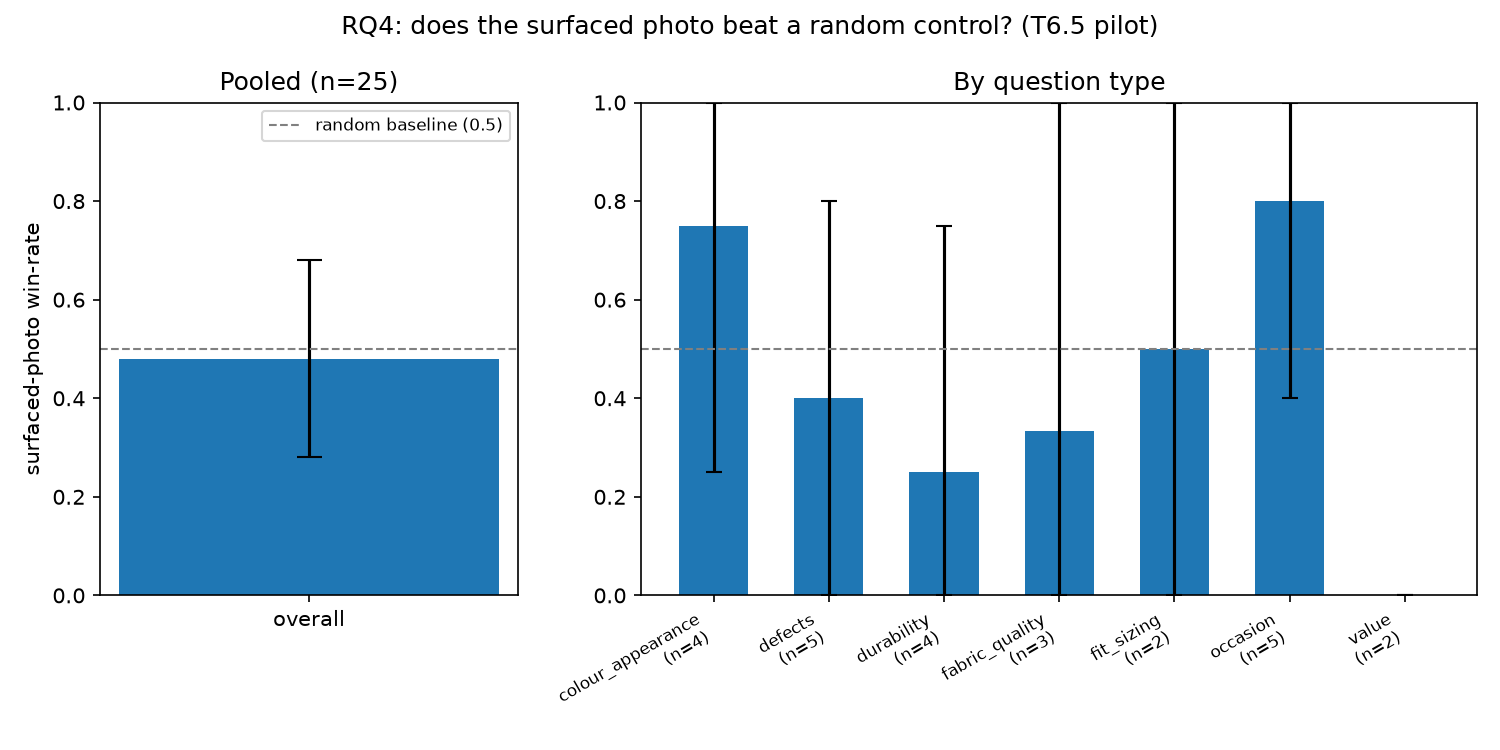

In [6]:
display(Image(filename=str(resolve_path("reports/figures/mm_photo_winrate_v1.png"))))

**Reading the headline number.** The 95% CI brackets 0.5 — at n=25 (below the ~30 pairs flagged as the underpowered threshold before any judge quota was spent, M6.md T6.5), this is an honest null result, not evidence the pipeline's photo surfacing doesn't work. It means this pilot's sample size cannot yet distinguish "no effect" from "a real but moderate effect".

## Per-question-type breakdown vs H4

H4 (PLAN.md §2) predicts photos help most on `colour_appearance` and `defects` — questions where the visual claim (a colour, a visible flaw) is exactly what a photo can show directly. The table above already carries this breakdown (one row per `type`); printed again here sorted by win-rate for readability.

In [7]:
by_type = winrate[winrate["group"] != "overall"].sort_values("win_rate", ascending=False)
display(by_type[["group", "n_pairs", "win_rate", "ci_lo", "ci_hi", "tie_rate"]])

,group,n_pairs,win_rate,ci_lo,ci_hi,tie_rate
6,occasion,5,0.800000,0.40,1.00,0.200000
1,colour_appearance,4,0.750000,0.25,1.00,0.250000
5,fit_sizing,2,0.500000,0.00,1.00,0.000000
2,defects,5,0.400000,0.00,0.80,0.400000
4,fabric_quality,3,0.333333,0.00,1.00,0.333333
3,durability,4,0.250000,0.00,0.75,0.750000
7,value,2,0.000000,0.00,0.00,1.000000


Every per-type count is small (2-5 pairs), so none of these differences are individually reliable — `occasion` and `colour_appearance` sit highest, `value` lowest (0/2, a question type photos structurally cannot answer, see the worked tie example in the appendix), broadly consistent with H4's direction but not something this sample size can confirm on its own.

## Order-agreement: did the position-bias control actually catch anything? (T6.4)

Every pair is judged twice — once with the surfaced photo shown as Photo A, once swapped — and only counts as a win if it wins *both* orders (`cragb.multimodal.vision_judge.judge_pair`). `order_agreement_rate` (already in the table above) is the fraction of pairs where the two orders agreed once the swap is accounted for.

In [8]:
n_pairs = int(overall["n_pairs"])
agreement_rate = overall["order_agreement_rate"]
n_disagree = round((1 - agreement_rate) * n_pairs)
print(
    f"order_agreement_rate={agreement_rate:.2f} -> "
    f"{n_pairs - n_disagree}/{n_pairs} pairs agreed across both orders, "
    f"{n_disagree} did not (folded into 'tie', never credited as a win either way)."
)

order_agreement_rate=0.88 -> 22/25 pairs agreed across both orders, 3 did not (folded into 'tie', never credited as a win either way).


So yes — the control did catch real position-driven inconsistency on a handful of pairs, not zero. Without it, those pairs' single-order answers could have been credited as wins purely because of which position the photo happened to be shown in.

## Human spot-check reliability (T6.6)

In [9]:
spotcheck = pd.read_csv(resolve_path("results/tables/mm_spotcheck_v1.csv"))
display(spotcheck)

,n,n_agree,raw_agreement,cohens_kappa
0,15,8,0.533333,0.204545


In [10]:
row = spotcheck.iloc[0]
usable = row["cohens_kappa"] >= 0.4
print(
    f"kappa={row['cohens_kappa']:.2f} (n={int(row['n'])}, "
    f"raw agreement={row['raw_agreement']:.0%}) -- "
    f"{'usable' if usable else 'BELOW the 0.4 usability bar'}."
)

kappa=0.20 (n=15, raw agreement=53%) -- BELOW the 0.4 usability bar.


κ=0.20 is below the 0.4 bar this project uses to call a judge validated (the same bar T4b.6 used for the text judge). Reading the actual disagreements (`reports/multimodal_examples_v1.md`'s fourth example) rather than only the number: every row where both the human and the judge said "A" agreed (7/7); nearly every disagreement is the judge calling `tie` where the human saw a marginal winner, and one case reads as genuine reasonable disagreement on a subjective task rather than an obvious judge error. Still: this is a real, reportable reliability limitation on the win-rate above, not a validated instrument.

## Limitations — read this before citing the win-rate number

- **Sample size.** n=25 usable pairs. The 95% CI on the pooled win-rate spans roughly 40 points and includes the 0.5 null — this pilot cannot yet distinguish "no effect" from "a real, moderate effect."
- **Coverage, not scarcity.** The corpus has plenty of image-bearing reviews (T6.1: 30,000 of 200,000 rows); the pilot's n is small because RAG-small's narrow k=5 context often misses them, not because photos are rare. A deeper retrieval `top_k` or a second, clearly-labelled oracle-photo arm (`best_photo_v1.jsonl`) would recover more pairs without changing what's already measured.
- **Judge reliability.** κ=0.20 (T6.6) is below this project's own 0.4 usability bar. The win-rate above should be read as *this specific judge's* opinion, not yet as a validated ground-truth measurement.
- **Evidence surfacing, not image-conditioned generation (PLAN.md §1.4 risk D).** The text generator never sees pixels — it only ever sees a `has_photo: yes/no` flag (`context_photo_flags` in the RAG-small transcripts). This pilot measures whether the photo a user *would be shown* next to the answer is good evidence, not whether the model reasoned over an image. No sentence in this report should imply otherwise.